## Integer Programming: Personnel Scheduling

A company has some required number of workers for each day of the week. They must hire employees to meet these requirements, so as to minimize the number of employees hired. Each employee starts working on a specific day of the week and works for 5 consecutive days (Monday to Friday, Tuesday to Saturday, etc.) while taking the other 2 days off.

Employees starting on Tuesday or Wednesday won't work on Monday, given that their working week will end before that. Employees starting on all other days will work on Monday. This can be generalized as: all employees can work on day $i$, except those starting on day $i+1\pmod{7}$ and $i+2\pmod{7}$.

For the given numbers of required workers, this can be formulated as below, where each $x_i$ is the number of employees starting on day $i$:

$$
\begin{array}{rllllllllllllll}
\min & x_0 & + & x_1 & + & x_2 & + & x_3 & + & x_4 & + & x_5 & + & x_6 & \\
\text{s.t.}
   & x_0 & + &     &   &     &   & x_3 & + & x_4 & + & x_5 & + & x_6 & \ge 110 \\
   & x_0 & + & x_1 & + &     &   &     &   & x_4 & + & x_5 & + & x_6 & \ge 80 \\
   & x_0 & + & x_1 & + & x_2 & + &     &   &     &   & x_5 & + & x_6 & \ge 150 \\
   & x_0 & + & x_1 & + & x_2 & + & x_3 & + &     &   &     &   & x_6 & \ge 30 \\
   & x_0 & + & x_1 & + & x_2 & + & x_3 & + & x_4 & + &     &   &     & \ge 70 \\
   &     &   & x_1 & + & x_2 & + & x_3 & + & x_4 & + & x_5 & + &     & \ge 160 \\
   &     &   &     &   & x_2 & + & x_3 & + & x_4 & + & x_5 & + & x_6 & \ge 120 \\
\end{array}
$$

This can be made more general and succinct as below, where $r_i$ is the number of employees required on day $i$, $D$ is the set of all days 0 (Monday) to 6 (Sunday), and $n$ is the total number of days (7):

$$
\begin{array}{rl}
\min & \displaystyle \sum_{i=0}^n x_i \\
\text{s.t.} & \displaystyle \sum_{j \in D \setminus \{i+1, i+2\} \mod n} x_j \ge r_i & \forall i \in \left\{ 0, 1, 2, \dots, n \right\} \\
& x_i \ge 0 & \forall i \in \left\{ 0, 1, 2, \dots, n \right\} \\
\end{array}
$$

Problem described in 2.9 of [Operations Research (1): Models and Applications](https://www.coursera.org/learn/operations-research-modeling/home/welcome).


In [ ]:
# Imports and input data

import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import LinearConstraint, milp

employees_required_per_day = np.array([
    110,
    80,
    150,
    30,
    70,
    160,
    120,
])

days = 7

In [ ]:
# Set objective and constraints

# Variables = [number of employees starting on day i]

# Minimize number of employees hired
coef = np.ones(days)

# For day i, all employees can work except those starting on day i+1 and i+2 (mod 7)
A = np.ones([days, days])
for i in range(days):
    A[i, (i + 1) % days] = 0
    A[i, (i + 2) % days] = 0
constraint = LinearConstraint(A, lb=employees_required_per_day)

array([[1., 0., 0., 1., 1., 1., 1.],
       [1., 1., 0., 0., 1., 1., 1.],
       [1., 1., 1., 0., 0., 1., 1.],
       [1., 1., 1., 1., 0., 0., 1.],
       [1., 1., 1., 1., 1., 0., 0.],
       [0., 1., 1., 1., 1., 1., 0.],
       [0., 0., 1., 1., 1., 1., 1.]])

In [ ]:
# Run solver

# Set all variables to be integers
integrality = np.ones_like(coef)

res = milp(c=coef, integrality=integrality, constraints=constraint)
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 164.0
              x: [ 2.000e+00  0.000e+00  5.400e+01  0.000e+00  1.400e+01
                   9.400e+01  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: 164.0
        mip_gap: 0.0

In [ ]:
# Print solution details

print(f"Total employees to hire: {res.fun:g}")
print()

# For each day, expand the count of employees hired on that day into an array of days on which they work
print("Employee working days:")
working_employees = np.ones([days, days])
for i in range(days):
    working_employees[i, (i + 5) % days] = 0
    working_employees[i, (i + 6) % days] = 0
working_employees = working_employees * res.x.reshape(-1, 1)

# Convert array to a DataFrame and add relevant information
df = pd.DataFrame(working_employees, index=pd.Series(list(calendar.day_name)))
df = pd.concat([
    df,
    df.sum().to_frame("sum").T,
    pd.Series(employees_required_per_day).to_frame("required").T,
])
df.index.name = "Starting on"
df.columns = pd.Series(list(calendar.day_name), name="Working on")
sum_row = pd.IndexSlice[df.index[df.index == "sum"], :]
df.map(int).style.map(lambda _: "font-weight: bold", subset=sum_row)

Total employees to hire: 164

Employee working days:


Working on,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Starting on,,,,,,,
Monday,2,2,2,2,2,0,0
Tuesday,0,0,0,0,0,0,0
Wednesday,0,0,54,54,54,54,54
Thursday,0,0,0,0,0,0,0
Friday,14,14,0,0,14,14,14
Saturday,94,94,94,0,0,94,94
Sunday,0,0,0,0,0,0,0
sum,110,110,150,56,70,162,162
required,110,80,150,30,70,160,120


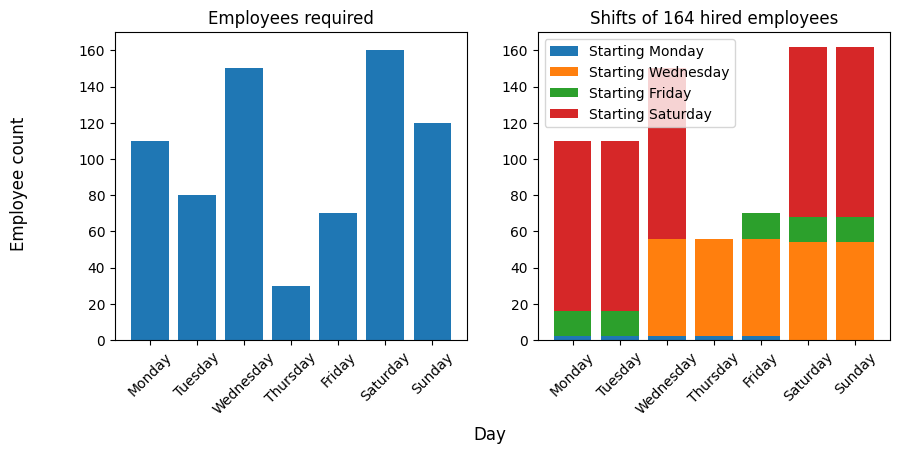

In [212]:
# Plot solution details

bins = np.arange(days)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

axes[0].bar(bins, employees_required_per_day)

cumulative = 0
for i, starting_day in enumerate(working_employees):
    if starting_day.any():
        axes[1].bar(bins, starting_day, bottom=cumulative, label=f"Starting " + calendar.day_name[i])
        cumulative += starting_day

axes[1].legend()
fig.supxlabel("Day", y=-0.15)
fig.supylabel("Employee count")
for i in range(2):
    axes[i].set_xticks(range(days))
    axes[i].tick_params(axis="x", labelrotation=45)
    axes[i].set_xticklabels(calendar.day_name)

axes[0].set_ybound(axes[1].get_ybound())
axes[0].set_title("Employees required")
axes[1].set_title(f"Shifts of {res.fun:g} hired employees")
pass